In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

import matplotlib.pyplot as plt

In [14]:
def normalize_smoking_history(x) -> str:
    """
    Normalize smoking_history values:
      - NaN/empty -> "no info"
      - "No info", "unknown", "unkown" -> "no info"
      - lower-case + trimmed + collapse multiple spaces
      - “former” and “not current” appear similar, but are treated as distinct categories, as they may reflect different levels of historical smoking exposure and therefore different risk profiles.
    """
    if pd.isna(x):
        return "no info"
    s = str(x).strip().lower()
    s = " ".join(s.split())
    if s in {"no info", "unknown", "unkown"}:
        return "no info"
    return s


def clean_gender(x) -> str:
    """Normalize gender strings (case/whitespace) into lower-case tokens."""
    if pd.isna(x):
        return "unknown"
    return " ".join(str(x).strip().lower().split())


def standardize_train_test(X_train: np.ndarray, X_test: np.ndarray):
    """Standardize features using training mean/std only (prevents leakage)."""
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std = np.where(std == 0, 1.0, std)
    return (X_train - mean) / std, (X_test - mean) / std


In [15]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    z = np.clip(z, -500, 500)  # numerical stability
    return 1.0 / (1.0 + np.exp(-z))


def compute_loss_and_grad(X: np.ndarray, y: np.ndarray, w: np.ndarray, b: float, l2: float):
    """
    Cross-entropy loss + optional L2 regularization on weights (not bias).
    Returns: (loss, grad_w, grad_b)
    """
    n = X.shape[0]
    logits = X @ w + b
    p = sigmoid(logits)

    eps = 1e-12
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

    if l2 > 0:
        loss += (l2 / (2 * n)) * np.sum(w * w)

    error = p - y
    grad_w = (X.T @ error) / n
    grad_b = np.mean(error)

    if l2 > 0:
        grad_w += (l2 / n) * w

    return loss, grad_w, grad_b


def fit_logreg_gd(X_train: np.ndarray, y_train: np.ndarray, lr=0.1, epochs=2000, l2=0.0, print_every=200):
    """
    Batch gradient descent for logistic regression.
    Returns: (w, b, loss_history)
    """
    n_features = X_train.shape[1]
    w = np.zeros(n_features, dtype=float)
    b = 0.0

    loss_history = []

    for epoch in range(1, epochs + 1):
        loss, grad_w, grad_b = compute_loss_and_grad(X_train, y_train, w, b, l2)
        w -= lr * grad_w
        b -= lr * grad_b

        loss_history.append(loss)

        if print_every and (epoch == 1 or epoch % print_every == 0 or epoch == epochs):
            print(f"Epoch {epoch:4d}/{epochs}  loss={loss:.6f}")

    return w, b, np.array(loss_history)


def predict_proba(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return sigmoid(X @ w + b)


def predict_label(X: np.ndarray, w: np.ndarray, b: float, threshold=0.5) -> np.ndarray:
    return (predict_proba(X, w, b) >= threshold).astype(int)


Gender categories (normalized): ['female', 'male', 'other']
Created gender columns: ['gender_male', 'gender_other']
Smoking categories (normalized): ['current', 'ever', 'former', 'never', 'no info', 'not current']
Created smoking columns: ['smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_no info', 'smoking_history_not current']
Dataset shape: (100000, 9)
Train size: (80000, 13), Test size: (20000, 13)
Epoch    1/2000  loss=0.693147
Epoch  200/2000  loss=0.166532
Epoch  400/2000  loss=0.139445
Epoch  600/2000  loss=0.129670
Epoch  800/2000  loss=0.124653
Epoch 1000/2000  loss=0.121641
Epoch 1200/2000  loss=0.119662
Epoch 1400/2000  loss=0.118283
Epoch 1600/2000  loss=0.117282
Epoch 1800/2000  loss=0.116532
Epoch 2000/2000  loss=0.115958

=== Evaluation on 20% test set ===
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[17836   464]
 [  474  1226]]
Accuracy : 0.9531
Precision: 0.7254
Recall   : 0.7212
F1 score : 0.7233


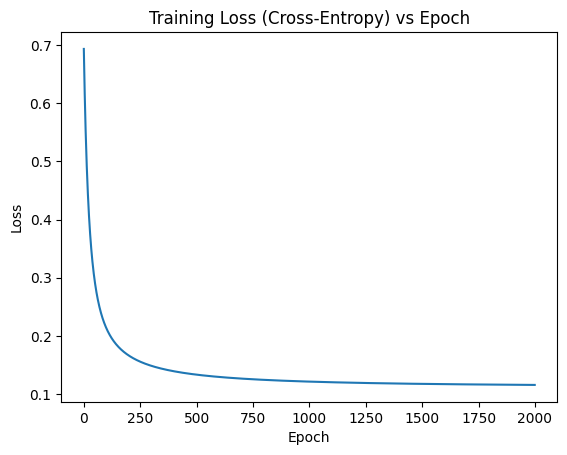

In [16]:
# ---- Load ----
df = pd.read_csv("diabetes_prediction_dataset.csv")

# ---- Target ----
target_col = "diabetes"
if target_col not in df.columns:
    raise ValueError(f"Expected target column '{target_col}' not found. Columns: {list(df.columns)}")

# ---- Clean categoricals ----
df["gender"] = df["gender"].apply(clean_gender)
df["smoking_history"] = df["smoking_history"].apply(normalize_smoking_history)

# ---- One-hot encode with drop_first=True to avoid perfect multicollinearity ----
gender_dummies = pd.get_dummies(df["gender"], prefix="gender", drop_first=True, dtype=int)
smoking_dummies = pd.get_dummies(df["smoking_history"], prefix="smoking_history", drop_first=True, dtype=int)

print("Gender categories (normalized):", sorted(df["gender"].unique()))
print("Created gender columns:", list(gender_dummies.columns))
print("Smoking categories (normalized):", sorted(df["smoking_history"].unique()))
print("Created smoking columns:", list(smoking_dummies.columns))

df_model = pd.concat(
    [df.drop(columns=["gender", "smoking_history"]), gender_dummies, smoking_dummies],
    axis=1
)

# ---- X, y ----
y = df_model[target_col].astype(int).to_numpy()
X_df = df_model.drop(columns=[target_col])

non_numeric = [c for c in X_df.columns if not pd.api.types.is_numeric_dtype(X_df[c])]
if non_numeric:
    raise ValueError(f"Non-numeric columns remain after encoding: {non_numeric}")

X = X_df.to_numpy(dtype=float)

# ---- 80/20 split (stratified) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Dataset shape: {df.shape}")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# ---- Standardize ----
X_train_std, X_test_std = standardize_train_test(X_train, X_test)

# ---- Train (GD + cross-entropy) ----
w, b, loss_history = fit_logreg_gd(
    X_train_std, y_train,
    lr=0.1,
    epochs=2000,
    l2=0.01, # "L2 regularisation to reduce overfitting
    print_every=200
)

# ---- Evaluate on test ----
y_pred = predict_label(X_test_std, w, b, threshold=0.3)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
acc = accuracy_score(y_test, y_pred)

print("\n=== Evaluation on 20% test set ===")
print("Confusion matrix [ [TN FP]\n                 [FN TP] ]:")
print(cm)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 score : {f1:.4f}")

# ---- Plot loss curve ----
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss (Cross-Entropy) vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


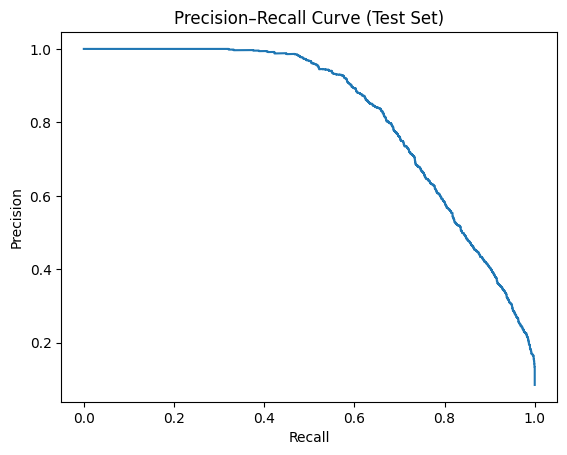

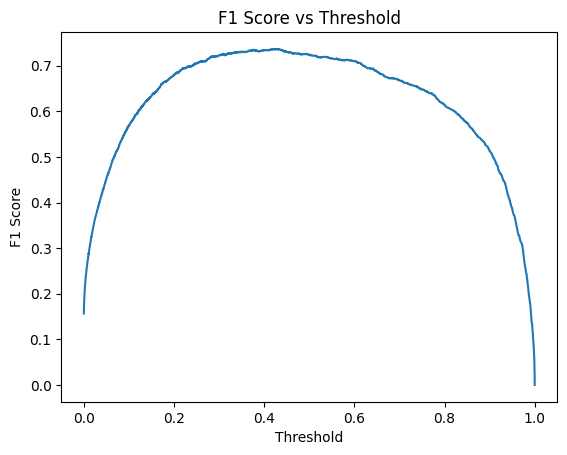

=== Threshold selection ===
Best-F1 threshold: 0.4299  (F1=0.7369)
Threshold for Recall ≥ 0.80: 0.1933

=== Evaluation @ Best-F1 threshold ===
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[18081   219]
 [  581  1119]]
Accuracy : 0.9600
Precision: 0.8363
Recall   : 0.6582
F1 score : 0.7367

=== Evaluation @ Recall ≥ 0.80 threshold ===
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[17330   970]
 [  340  1360]]
Accuracy : 0.9345
Precision: 0.5837
Recall   : 0.8000
F1 score : 0.6749


In [18]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, precision_recall_curve 
)

def eval_at_threshold(y_true, y_prob, thr: float):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "threshold": thr,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

# 1) Get predicted probabilities on the test set
y_prob = predict_proba(X_test_std, w, b)

# 2) Precision-Recall curve (scikit computes curve points + thresholds)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
# Note: precision/recall have length = len(thresholds)+1

# 3) Compute F1 for each threshold returned by precision_recall_curve
# Use precision[1:], recall[1:] aligned with thresholds
eps = 1e-12
f1s = 2 * (precision[1:] * recall[1:]) / (precision[1:] + recall[1:] + eps)

best_idx = int(np.argmax(f1s))
best_f1_thr = float(thresholds[best_idx])
best_f1 = float(f1s[best_idx])

# 4) Find smallest threshold that achieves a target recall
target_recall = 0.80
# recall decreases as threshold increases (generally), so scan thresholds from low->high
recalls_for_thresholds = recall[1:]  # aligned with thresholds
eligible = np.where(recalls_for_thresholds >= target_recall)[0]
thr_for_target_recall = None
if len(eligible) > 0:
    thr_for_target_recall = float(thresholds[eligible[-1]])
    # eligible[-1] gives the highest threshold still meeting the recall target

# 5) Plot Precision-Recall curve
plt.figure()
plt.plot(recall, precision)
plt.title("Precision–Recall Curve (Test Set)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

plt.figure()
plt.plot(thresholds, f1s)
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

print("=== Threshold selection ===")
print(f"Best-F1 threshold: {best_f1_thr:.4f}  (F1={best_f1:.4f})")

if thr_for_target_recall is not None:
    print(f"Threshold for Recall ≥ {target_recall:.2f}: {thr_for_target_recall:.4f}")
else:
    print(f"No threshold found achieving Recall ≥ {target_recall:.2f} (try lower target).")

# 6) Evaluate and print results at chosen thresholds
print("\n=== Evaluation @ Best-F1 threshold ===")
res_best = eval_at_threshold(y_test, y_prob, best_f1_thr)
print("Confusion matrix [ [TN FP]\n                 [FN TP] ]:")
print(res_best["confusion_matrix"])
print(f'Accuracy : {res_best["accuracy"]:.4f}')
print(f'Precision: {res_best["precision"]:.4f}')
print(f'Recall   : {res_best["recall"]:.4f}')
print(f'F1 score : {res_best["f1"]:.4f}')

if thr_for_target_recall is not None:
    print(f"\n=== Evaluation @ Recall ≥ {target_recall:.2f} threshold ===")
    res_r = eval_at_threshold(y_test, y_prob, thr_for_target_recall)
    print("Confusion matrix [ [TN FP]\n                 [FN TP] ]:")
    print(res_r["confusion_matrix"])
    print(f'Accuracy : {res_r["accuracy"]:.4f}')
    print(f'Precision: {res_r["precision"]:.4f}')
    print(f'Recall   : {res_r["recall"]:.4f}')
    print(f'F1 score : {res_r["f1"]:.4f}')
